## Imports

In [1]:
import os
import random
from copy import deepcopy

import cv2
import numpy as np
import torch
from torch import nn

from torch.utils.data import Dataset, WeightedRandomSampler, DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import albumentations as A
from albumentations.pytorch import ToTensorV2

from shared.early_stopping import EarlyStopping
from shared.mat_reader import MatReader
from shared.constants import CLASS_NAMES, DEVICE
from architectures.binary_ce.dataset import BinaryCEDataset
from architectures.binary_ce.model import BinaryCEModel

print(f"Using device: {DEVICE}")

Using device: mps


## Feature Extraction

In [2]:
from shared.utils import get_n_splits

mat_reader = MatReader("/data/lampe/dataset")

n_splits = get_n_splits(mat_reader)
n_splits = 10

## StratifiedGroupKFolds

In [3]:
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True)
# sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)

print(f"# splits: {n_splits}")

X, y, groups = mat_reader.images, mat_reader.class_labels, mat_reader.patient_ids

train_losses = [[] for _ in range(n_splits)]
train_targets = [0] * n_splits
train_preds = [0] * n_splits

val_losses = [[] for _ in range(n_splits)]
val_targets = [0] * n_splits
val_preds = [0] * n_splits
val_probs = [0] * n_splits

accuracies = [0] * n_splits
min_val_losses = [(10, 9999)] * n_splits # (epoch number, val loss)

best_model_state_dict = None
min_val_loss_for_save = 9999

for fold, (train_indices, val_indices) in enumerate(sgkf.split(X, y, groups=groups)):
    # minimum loss across epochs in the current fold
    min_val_loss = 9999
    
    train_dataset = BinaryCEDataset(mat_reader, eff_fov_indices=train_indices.tolist(), train=True)
    val_dataset = BinaryCEDataset(mat_reader, eff_fov_indices=val_indices.tolist(), train=False, normalizer_override=train_dataset.normalizer)

    train_labels = y[train_indices]
    class_counts = np.bincount(train_labels, minlength=len(CLASS_NAMES))
    class_weights = np.zeros_like(class_counts, dtype=np.float32)
    np.divide(1.0, class_counts, out=class_weights, where=class_counts > 0)
    sample_weights = class_weights[train_labels]
    
    sampler = WeightedRandomSampler(
        weights=sample_weights, 
        # num_samples=len(sample_weights), 
        num_samples=len(sample_weights) * 2,
        replacement=True
    )

    train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    model = BinaryCEModel().to(DEVICE)

    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=1e-4, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6
    )
    criterion = nn.BCEWithLogitsLoss()
    early_stopping = EarlyStopping(patience=20)

    num_epochs = 100
    unfreezing_guard = True

    for epoch in range(num_epochs):
        model.train()
        
        # epoch-level across all batches
        running_train_loss = 0.0
        epoch_train_targets = []
        epoch_train_preds = []

        custom_threshold = 0.5
        
        for batch in train_loader:
            optimizer.zero_grad() # gradient accumulates from start of epoch without this
            images, class_labels, patient_ids = batch
            # print(np.unique(class_labels, return_counts=True))
    
            inputs = images.to(DEVICE)
            logits = model(inputs).squeeze(1) # [batch_size, 1] -> [batch_size]
            # preds = (logits > 0).long()
            
            probs = torch.sigmoid(logits)
            preds = (probs > custom_threshold).long()
            
            epoch_train_targets.extend(class_labels.tolist())
            epoch_train_preds.extend(preds.tolist())

            targets = class_labels.to(DEVICE).float()
            loss = criterion(logits, targets)
            running_train_loss += loss.item() * images.size(0)
            
            loss.backward()
            optimizer.step()
    
        train_loss = running_train_loss / len(train_dataset)
        train_losses[fold].append(train_loss) # stores losses across all epochs

        with torch.no_grad():
            model.eval()
            
            running_val_loss = 0.0 # across batches
            epoch_val_targets = []
            epoch_val_preds = []
            epoch_val_probs = [] # ROC AUC
            
            for batch in val_loader:
                # NOTE: DataLoader converts class_labels: np.ndarray --> torch.Tensor
                images, class_labels, patient_ids = batch
                
                inputs = images.to(DEVICE)
                logits = model(inputs).squeeze(1)
                # preds = (logits > 0).long()

                probs = torch.sigmoid(logits)
                preds = (probs > custom_threshold).long()
                
                epoch_val_targets.extend(class_labels.tolist())
                epoch_val_preds.extend(preds.tolist())
                epoch_val_probs.extend(probs.tolist())

                targets = class_labels.to(DEVICE).float()
                loss = criterion(logits, targets)
                running_val_loss += loss.item() * images.size(0)
                
            val_loss = running_val_loss / len(val_dataset)
            val_losses[fold].append(val_loss) # stores losses across all epochs

            acc = float(accuracy_score(epoch_val_targets, epoch_val_preds))

            # epoch with lowest validation loss
            if val_loss < min_val_loss:
                min_val_loss = val_loss
                min_val_losses[fold] = (epoch, val_loss) # for matplotlib .scatter()

                # targets and preds for this fold
                train_targets[fold] = epoch_train_targets
                train_preds[fold] = epoch_train_preds
                val_targets[fold] = epoch_val_targets
                val_preds[fold] = epoch_val_preds

                # accuracy for this fold
                accuracies[fold] = acc

                # probablities (for ROC AUC)
                val_probs[fold] = epoch_val_probs

            if val_loss < min_val_loss_for_save:
                best_model_state_dict = deepcopy(model.state_dict())
                min_val_loss_for_save = val_loss
                print(f"New best overall found: Fold {fold + 1}, Val Loss: {val_loss}.")
        
        scheduler.step(val_loss)
        early_stopping(val_loss)
        
        if early_stopping.early_stop:
            if unfreezing_guard:
                unfreezing_guard = False
                print(f"(Fold {fold + 1}): Unfreezing layer4 of ResNet50...")
                layer4_params = model.model.layer4.parameters()
                for param in layer4_params:
                    param.requires_grad = True
                optimizer.add_param_group({
                    'params': layer4_params,
                    'lr': 1e-5 # tinier LR than fc head
                })
                early_stopping = EarlyStopping(patience=20) # reset EarlyStopping counters
            else:
                print(f"Early stopping triggered at epoch {epoch + 1}")
                break

        print(
            (
                f"- Fold {fold + 1}/{n_splits}"
                f"- Epoch {epoch + 1}/{num_epochs}"
                f"- Train Loss: {train_loss:.4f}"
                f"- Val Loss: {val_loss:.4f}"
                f"- Accuracy: {acc:.4f}"
            )
        )

# save best overall model.pth
torch.save(best_model_state_dict, "/Users/james/GitHub/lampe/model_v3.pth")

# splits: 10
New best overall found: Fold 1, Val Loss: 0.6864209175109863.
- Fold 1/10- Epoch 1/100- Train Loss: 1.2946- Val Loss: 0.6864- Accuracy: 0.5000
New best overall found: Fold 1, Val Loss: 0.6625702381134033.
- Fold 1/10- Epoch 2/100- Train Loss: 1.1559- Val Loss: 0.6626- Accuracy: 0.5000
New best overall found: Fold 1, Val Loss: 0.6200047135353088.
- Fold 1/10- Epoch 3/100- Train Loss: 1.0330- Val Loss: 0.6200- Accuracy: 0.8125
New best overall found: Fold 1, Val Loss: 0.5722368359565735.
- Fold 1/10- Epoch 4/100- Train Loss: 0.9900- Val Loss: 0.5722- Accuracy: 0.9375
New best overall found: Fold 1, Val Loss: 0.5346158742904663.
- Fold 1/10- Epoch 5/100- Train Loss: 0.9321- Val Loss: 0.5346- Accuracy: 0.9375
New best overall found: Fold 1, Val Loss: 0.49885815382003784.
- Fold 1/10- Epoch 6/100- Train Loss: 0.8908- Val Loss: 0.4989- Accuracy: 0.9375
New best overall found: Fold 1, Val Loss: 0.48182687163352966.
- Fold 1/10- Epoch 7/100- Train Loss: 0.7943- Val Loss: 0.4818- A

## Loss Curves, ROC AUC

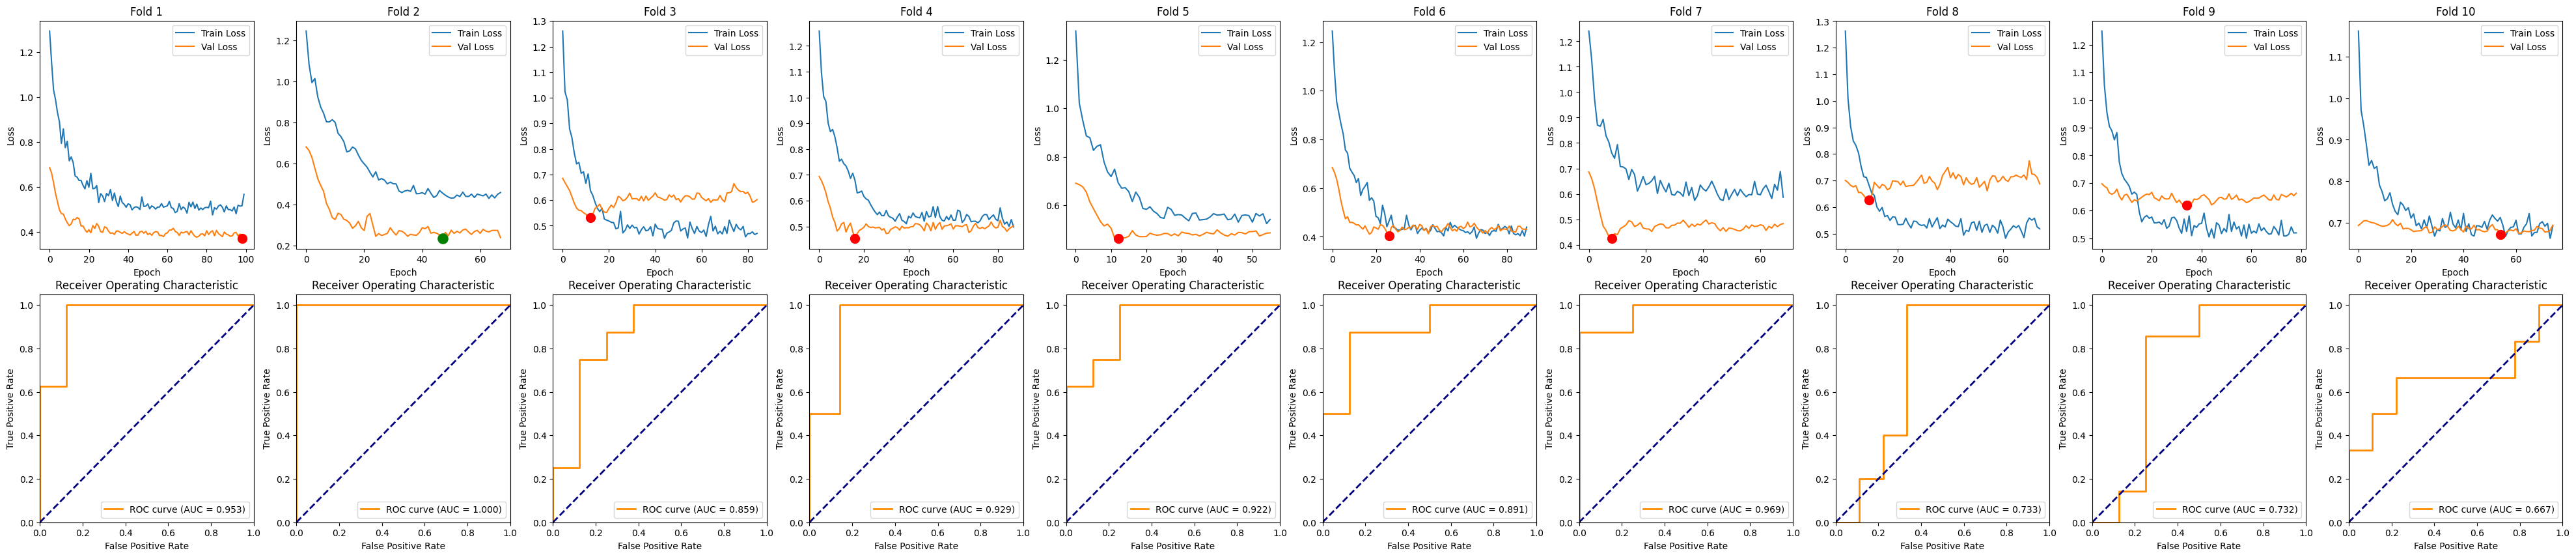

In [4]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(2, n_splits, figsize=(5 * n_splits, 10))

# fig_title = "Report"
# fig.suptitle(fig_title)

# ax[0].imshow(img)
# ax[0].set_title('Original RGB')
# ax[0].axis('off')

auc_scores = []

for i in range(n_splits):
    # loss curves
    ax[0, i].plot(train_losses[i], label="Train Loss")
    ax[0, i].plot(val_losses[i], label="Val Loss")
    ax[0, i].set_xlabel("Epoch")
    ax[0, i].set_ylabel("Loss")
    ax[0, i].set_title(f"Fold {i + 1}")
    ax[0, i].legend()

    # model snapshots
    _best_epoch, min_val_loss = min_val_losses[i]
    if min_val_loss == min_val_loss_for_save:
        ax[0, i].scatter(*min_val_losses[i], color='green', s=120, zorder=5, label='Best Overall')
    else:
        ax[0, i].scatter(*min_val_losses[i], color='red', s=100, zorder=5, label='Snapshot')

    # ROC AUC
    auc_score = roc_auc_score(val_targets[i], val_probs[i])
    auc_scores.append(auc_score)
    fpr, tpr, thresholds = roc_curve(val_targets[i], val_probs[i])
    ax[1, i].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.3f})')
    ax[1, i].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random guessing line
    ax[1, i].set_xlim([0.0, 1.0])
    ax[1, i].set_ylim([0.0, 1.05])
    ax[1, i].set_xlabel('False Positive Rate')
    ax[1, i].set_ylabel('True Positive Rate')
    ax[1, i].set_title('Receiver Operating Characteristic')
    ax[1, i].legend(loc="lower right")


## Performance Metrics

In [5]:
for fold in range(n_splits):
    cm = confusion_matrix(train_targets[fold], train_preds[fold], labels=list(range(len(CLASS_NAMES))))
    print(f"Train Confusion Matrix (Fold {fold+1}):")
    header = "          " + "  ".join(f"{name:>10}" for name in CLASS_NAMES)
    print(header)
    for i, row in enumerate(cm):
        row_str = "  ".join(f"{v:>10}" for v in row)
        print(f"{CLASS_NAMES[i]:>10}  {row_str}")

Train Confusion Matrix (Fold 1):
                 HGC         IDC
       HGC         128           9
       IDC           1         138
Train Confusion Matrix (Fold 2):
                 HGC         IDC
       HGC         121           0
       IDC           1         156
Train Confusion Matrix (Fold 3):
                 HGC         IDC
       HGC         114           9
       IDC           7         146
Train Confusion Matrix (Fold 4):
                 HGC         IDC
       HGC         129          13
       IDC           6         130
Train Confusion Matrix (Fold 5):
                 HGC         IDC
       HGC         134          11
       IDC           9         122
Train Confusion Matrix (Fold 6):
                 HGC         IDC
       HGC         132           1
       IDC           0         143
Train Confusion Matrix (Fold 7):
                 HGC         IDC
       HGC         106          27
       IDC           2         141
Train Confusion Matrix (Fold 8):
               

In [6]:
for fold in range(n_splits):
    cm = confusion_matrix(val_targets[fold], val_preds[fold], labels=list(range(len(CLASS_NAMES))))
    print(f"Validation Confusion Matrix (Fold {fold+1} - {accuracies[fold] * 100:.2f}%):")
    header = "          " + "  ".join(f"{name:>10}" for name in CLASS_NAMES)
    print(header)
    for i, row in enumerate(cm):
        row_str = "  ".join(f"{v:>10}" for v in row)
        print(f"{CLASS_NAMES[i]:>10}  {row_str}")


Validation Confusion Matrix (Fold 1 - 87.50%):
                 HGC         IDC
       HGC           7           1
       IDC           1           7
Validation Confusion Matrix (Fold 2 - 100.00%):
                 HGC         IDC
       HGC           9           0
       IDC           0           6
Validation Confusion Matrix (Fold 3 - 62.50%):
                 HGC         IDC
       HGC           7           1
       IDC           5           3
Validation Confusion Matrix (Fold 4 - 73.33%):
                 HGC         IDC
       HGC           6           1
       IDC           3           5
Validation Confusion Matrix (Fold 5 - 75.00%):
                 HGC         IDC
       HGC           7           1
       IDC           3           5
Validation Confusion Matrix (Fold 6 - 87.50%):
                 HGC         IDC
       HGC           7           1
       IDC           1           7
Validation Confusion Matrix (Fold 7 - 93.75%):
                 HGC         IDC
       HGC         

## Report

In [7]:
print("\n--- Final Results ---")
print(
    f"Mean CV Accuracy: {np.mean(accuracies) * 100:.2f}% ± {np.std(accuracies) * 100:.2f}%"
)
print(
    f"Mean CV AUC: {np.mean(auc_scores) * 100:.2f}% ± {np.std(auc_scores) * 100:.2f}%"
)

print("\nGlobal Classification Report:")
print(classification_report(np.concatenate(val_targets), np.concatenate(val_preds), labels=list(range(len(CLASS_NAMES))), target_names=CLASS_NAMES)) # must take only from last epochs

print(f"ACC: {accuracies}")
print(f"AUC: {auc_scores}")


--- Final Results ---
Mean CV Accuracy: 76.43% ± 15.21%
Mean CV AUC: 86.54% ± 10.91%

Global Classification Report:
              precision    recall  f1-score   support

         HGC       0.79      0.76      0.78        82
         IDC       0.74      0.78      0.76        72

    accuracy                           0.77       154
   macro avg       0.77      0.77      0.77       154
weighted avg       0.77      0.77      0.77       154

ACC: [0.875, 1.0, 0.625, 0.7333333333333333, 0.75, 0.875, 0.9375, 0.7142857142857143, 0.6666666666666666, 0.4666666666666667]
AUC: [0.953125, 1.0, 0.859375, 0.9285714285714286, 0.921875, 0.890625, 0.96875, 0.7333333333333334, 0.7321428571428571, 0.6666666666666666]
